In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob
from arcgis.gis import GIS
#gis = GIS(profile="your_online_profile")
gis = GIS(username="api_data_owner", password="data.owner8")

In [2]:
from arcgis.features.manage_data import dissolve_boundaries

In [3]:
item = gis.content.get('4e0ad45cc99e4f63ae5fcbc39ad9010d')

<Item title:"Merge2" type:Feature Layer Collection owner:api_data_owner>
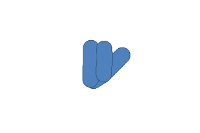

In [4]:
item

In [5]:
buffers = item.layers[0]

In [6]:
import pandas as pd

In [7]:
sdf = pd.DataFrame.spatial.from_layer(buffers)

In [8]:
from datetime import datetime
dissolve = dissolve_boundaries(buffers,
                               output_name='DissolvedLayers' + str(datetime.now().microsecond),
                               multi_part_features=False, future=True)
assert isinstance(dissolve, GPJob)
dissolve

<DissolveBoundaries GP Job: j931caa8868024807afe5a3beeafe3846>

In [9]:
assert isinstance(dissolve.result(), Item)

In [10]:
dissolve.result().delete()

True

In [11]:
items = gis.content.get('b79afd0ddf334e91a5d041f2ba5dceae')

<Item title:"District Boundary 2006" type:Feature Layer Collection owner:GIS@NISR>
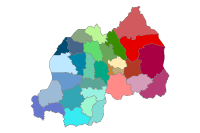

In [12]:
items

In [ ]:
test2 = dissolve_boundaries(input_layer=items.layers[0],
                    dissolve_fields=['Prov_Name'])
assert isinstance(test2, FeatureCollection)

In [16]:
test2 = dissolve_boundaries(input_layer=items.layers[0],
                    dissolve_fields=['Prov_Name'], future=True)
assert isinstance(test2.result(), FeatureCollection)

In [13]:
test2 = dissolve_boundaries(input_layer=items.layers[0],
                    dissolve_fields=['Prov_Name'],
                    output_name="DissolveBoundariesTest" + str(datetime.now().microsecond))
assert isinstance(test2, Item)

In [14]:
test2.delete()

True

In [ ]:
item3 = gis.content.get('d8e6e822e6b44d80b4d3b5fe7538576d')

In [ ]:
item3

In [ ]:
item3.layers

In [ ]:
test3 = dissolve_boundaries(input_layer=item3.layers[0],
                            dissolve_fields=["CLASS","ST"],
                            summary_fields=["POP12_SQMI MEAN"],
                            output_name="DissolveBoundariesTest" + str(datetime.now().microsecond))

In [ ]:
test3

In [ ]:
test3.delete()

In [ ]:
item4 = gis.content.get('48f9af87daa241c4b267c5931ad3b226')

In [ ]:
item4

In [ ]:
test4 = dissolve_boundaries(input_layer=item4.layers[0],
                            dissolve_fields=["STATE_NAME"],
                            summary_fields=["POPULATION STDDEV"],
                            output_name="DissolveBoundariesTest" + str(datetime.now().microsecond))

In [ ]:
test4

In [ ]:
test4.delete()